In [1]:
import pickle

# Load the splits into this notebook's memory
with open('../data/processed_splits.pkl', 'rb') as f:
    X_train_balanced, X_val, X_test, y_train_balanced, y_val, y_test = pickle.load(f)

print("✓ Data successfully imported and ready for modeling!")

✓ Data successfully imported and ready for modeling!


Training Logistic Regression...

--- Logistic Regression Validation Results ---
Accuracy:  0.6890
F1-Score:  0.4723
AUC Score: 0.7209

Generating Confusion Matrix...


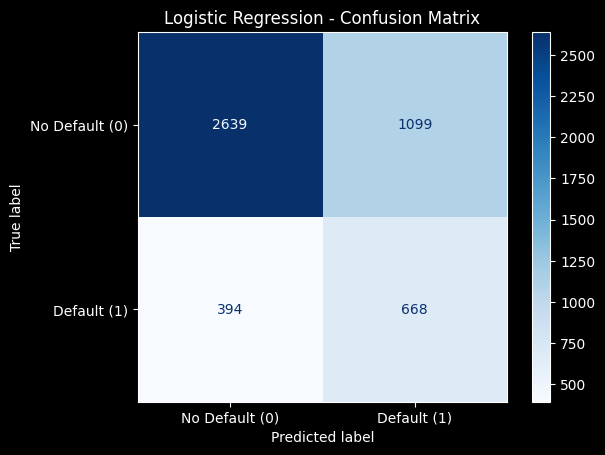

In [2]:
# 1. Import the necessary tools from scikit-learn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 2. Initialize the model
# We set max_iter=1000 to ensure the model has enough time to find the best mathematical line
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# 3. Train the model (Fit)
# CRITICAL: We only let the model learn from the balanced training data
print("Training Logistic Regression...")
log_reg.fit(X_train_balanced, y_train_balanced)

# 4. Make Predictions on the Validation Set
# We test its knowledge on the X_val set (which it has never seen before)
y_val_pred = log_reg.predict(X_val)

# We also need the predicted probabilities (rather than just 0 or 1) to calculate the AUC score
y_val_prob = log_reg.predict_proba(X_val)[:, 1]

# 5. Calculate Metrics
accuracy = accuracy_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
auc = roc_auc_score(y_val, y_val_prob)

print("\n--- Logistic Regression Validation Results ---")
print(f"Accuracy:  {accuracy:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"AUC Score: {auc:.4f}")

# 6. Plot the Confusion Matrix
print("\nGenerating Confusion Matrix...")
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])
disp.plot(cmap='Blues')
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

Training Decision Tree...

--- Decision Tree Validation Results ---
Accuracy:  0.7515
F1-Score:  0.5172
AUC Score: 0.7487

Generating Feature Importance Plot...


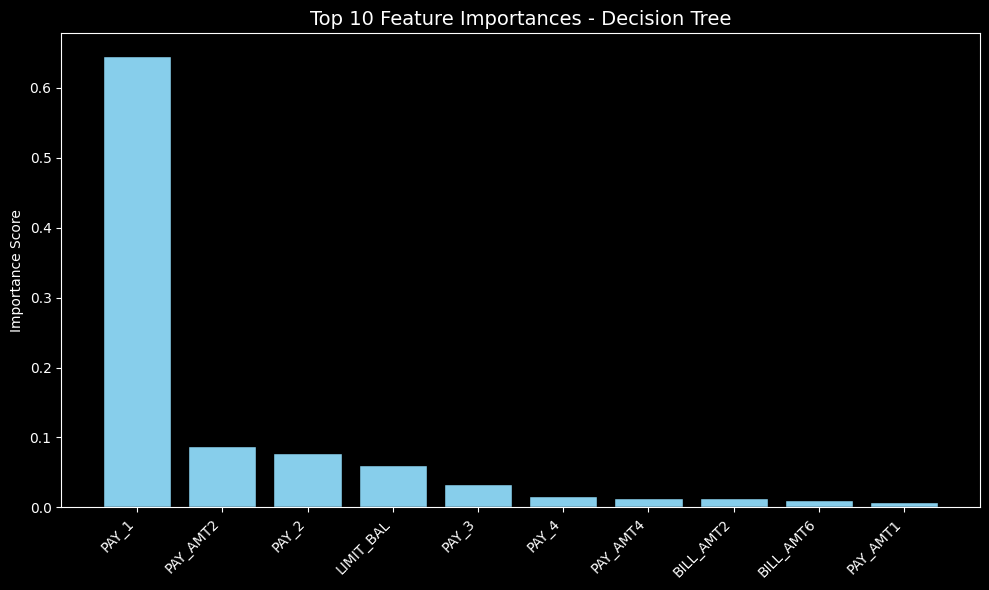

In [5]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# 1. Initialize the Decision Tree
# We set max_depth=5 to stop the tree from growing too deep and "memorizing" the training data (overfitting)
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)

# 2. Train the model
print("Training Decision Tree...")
dt_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the Validation Set
y_val_pred_dt = dt_model.predict(X_val)
y_val_prob_dt = dt_model.predict_proba(X_val)[:, 1]

# 4. Calculate Metrics
acc_dt = accuracy_score(y_val, y_val_pred_dt)
f1_dt = f1_score(y_val, y_val_pred_dt)
auc_dt = roc_auc_score(y_val, y_val_prob_dt)

print("\n--- Decision Tree Validation Results ---")
print(f"Accuracy:  {acc_dt:.4f}")
print(f"F1-Score:  {f1_dt:.4f}")
print(f"AUC Score: {auc_dt:.4f}")

# 5. Plot the Top 10 Feature Importances
print("\nGenerating Feature Importance Plot...")
plt.figure(figsize=(10, 6))

# Extract importances and sort them
importances = dt_model.feature_importances_
features = X_train_balanced.columns
indices = np.argsort(importances)[::-1] # Sort from highest to lowest

# Plot the top 10 most important features
plt.title("Top 10 Feature Importances - Decision Tree", fontsize=14)
plt.bar(range(10), importances[indices][:10], align="center", color='skyblue', edgecolor='black')
plt.xticks(range(10), [features[i] for i in indices[:10]], rotation=45, ha='right')
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# 1. Initialize KNN
# We will check the 5 closest neighbors (n_neighbors=5 is a standard starting point)
knn_model = KNeighborsClassifier(n_neighbors=5)

# 2. Train the model
# Warning: KNN can take a little longer to predict because it calculates distances to all 29,906 balanced training points!
print("Training K-Nearest Neighbors...")
knn_model.fit(X_train_balanced, y_train_balanced)

# 3. Make Predictions on the Validation Set
print("Calculating distances and predicting (this might take a few seconds)...")
y_val_pred_knn = knn_model.predict(X_val)
y_val_prob_knn = knn_model.predict_proba(X_val)[:, 1]

# 4. Calculate Metrics
acc_knn = accuracy_score(y_val, y_val_pred_knn)
f1_knn = f1_score(y_val, y_val_pred_knn)
auc_knn = roc_auc_score(y_val, y_val_prob_knn)

print("\n--- K-Nearest Neighbors Validation Results ---")
print(f"Accuracy:  {acc_knn:.4f}")
print(f"F1-Score:  {f1_knn:.4f}")
print(f"AUC Score: {auc_knn:.4f}")

Training K-Nearest Neighbors...
Calculating distances and predicting (this might take a few seconds)...

--- K-Nearest Neighbors Validation Results ---
Accuracy:  0.6646
F1-Score:  0.4417
AUC Score: 0.6790


--- Model Comparison Table (Validation Set) ---


,Model,Accuracy,F1-Score,AUC Score
0,Logistic Regression,0.6890,0.4723,0.7209
1,Decision Tree,0.7515,0.5172,0.7487
2,K-Nearest Neighbors,0.6646,0.4417,0.6790




Running final evaluation of the Decision Tree on the UNSEEN Test Set...
Final Test Accuracy:  0.7430
Final Test F1-Score:  0.4964
Final Test AUC:       0.7421

Generating Final Test Confusion Matrix for Error Analysis...


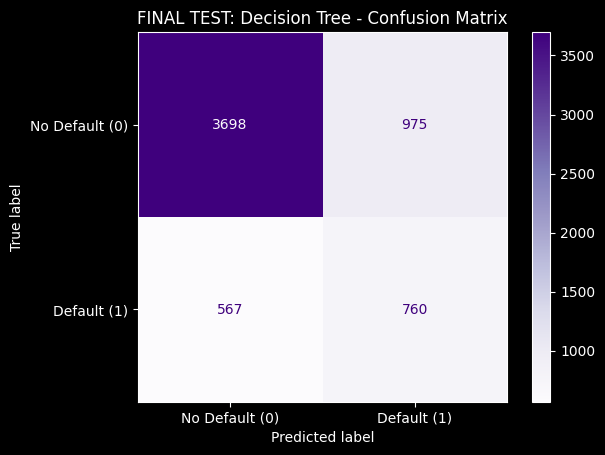

In [7]:
import pandas as pd

# 1. Create a Comparison Table for the Validation Results
results_dict = {
    "Model": ["Logistic Regression", "Decision Tree", "K-Nearest Neighbors"],
    "Accuracy": [accuracy, acc_dt, acc_knn],
    "F1-Score": [f1, f1_dt, f1_knn],
    "AUC Score": [auc, auc_dt, auc_knn]
}

results_df = pd.DataFrame(results_dict)
# Round the numbers for a cleaner table
results_df = results_df.round(4)

print("--- Model Comparison Table (Validation Set) ---")
display(results_df)

print("\n======================================================\n")

# 2. THE FINAL TEST EVALUATION
# We only do this ONCE using our winning model (Decision Tree)
print("Running final evaluation of the Decision Tree on the UNSEEN Test Set...")

y_test_pred = dt_model.predict(X_test)
y_test_prob = dt_model.predict_proba(X_test)[:, 1]

test_acc = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_prob)

print(f"Final Test Accuracy:  {test_acc:.4f}")
print(f"Final Test F1-Score:  {test_f1:.4f}")
print(f"Final Test AUC:       {test_auc:.4f}")

# 3. Error Analysis prep (Identifying False Positives & False Negatives)
print("\nGenerating Final Test Confusion Matrix for Error Analysis...")
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['No Default (0)', 'Default (1)'])
disp_test.plot(cmap='Purples')
plt.title("FINAL TEST: Decision Tree - Confusion Matrix")
plt.show()